# Provided flowToColor function

In [1]:
'''
python by:  youngjung uh, Clova ML, Naver
contact:    youngjung.uh@navercorp.com
date:       17 Dec 2018

-------------------------------------------------------------------
----- below comment came from the original (flowToColor.m) --------
-------------------------------------------------------------------
flowToColor(flow, maxFlow) flowToColor color codes flow field, normalize
based on specified value,

flowToColor(flow) flowToColor color codes flow field, normalize
based on maximum flow present otherwise

According to the c++ source code of Daniel Scharstein
Contact: schar@middlebury.edu

Author: Deqing Sun, Department of Computer Science, Brown University
Contact: dqsun@cs.brown.edu
$Date: 2007-10-31 18:33:30 (Wed, 31 Oct 2006) $

Copyright 2007, Deqing Sun.

                        All Rights Reserved

Permission to use, copy, modify, and distribute this software and its
documentation for any purpose other than its incorporation into a
commercial product is hereby granted without fee, provided that the
above copyright notice appear in all copies and that both that
copyright notice and this permission notice appear in supporting
documentation, and that the name of the author and Brown University not be used in
advertising or publicity pertaining to distribution of the software
without specific, written prior permission.

THE AUTHOR AND BROWN UNIVERSITY DISCLAIM ALL WARRANTIES WITH REGARD TO THIS SOFTWARE,
INCLUDING ALL IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR ANY
PARTICULAR PURPOSE.  IN NO EVENT SHALL THE AUTHOR OR BROWN UNIVERSITY BE LIABLE FOR
ANY SPECIAL, INDIRECT OR CONSEQUENTIAL DAMAGES OR ANY DAMAGES
WHATSOEVER RESULTING FROM LOSS OF USE, DATA OR PROFITS, WHETHER IN AN
ACTION OF CONTRACT, NEGLIGENCE OR OTHER TORTIOUS ACTION, ARISING OUT OF
OR IN CONNECTION WITH THE USE OR PERFORMANCE OF THIS SOFTWARE.
'''

import numpy as np

def flowToColor(flow, maxflow=None, verbose=False):
    '''
    args
        flow (numpy array) height x width x 2
    return
        img_color (numpy array) height x width x 3
    '''

    UNKNOWN_FLOW_THRESH = 5e2
    eps = 1e-6

    height, widht, nBands = flow.shape

    if nBands != 2:
        exit('flowToColor: image must have two bands')

    u = flow[:, :, 0]
    v = flow[:, :, 1]

    maxu = -999
    maxv = -999

    minu = 999
    minv = 999
    maxrad = -1

    # fix unknown flow
    idxUnknown = (abs(u) > UNKNOWN_FLOW_THRESH) | (abs(v) > UNKNOWN_FLOW_THRESH)
    u[idxUnknown] = 0
    v[idxUnknown] = 0

    maxu = max(maxu, u.max())
    minu = min(minu, u.min())

    maxv = max(maxv, v.max())
    minv = min(minv, v.min())

    rad = np.sqrt(u ** 2 + v ** 2)
    maxrad = max(maxrad, rad.max())

    if verbose:
        print('max flow: %.4f flow range: u = %.3f .. %.3f; v = %.3f .. %.3f\n' %
              (maxrad, minu, maxu, minv, maxv))

    if maxflow is not None:
        if maxflow > 0:
            maxrad = maxflow

    u = u / (maxrad + eps)
    v = v / (maxrad + eps)

    img = computeColor(u, v)

    # unknown flow
    # IDX = repmat(idxUnknown, [1, 1, 3])
    img[idxUnknown] = 0

    return img

def computeColor(u, v, cast_uint8=True):
    '''
    args
        u (numpy array) height x width
        v (numpy array) height x width
        cast_uint8 (bool) set False to have image range 0-1 (np.float32)
    return
        img_color (numpy array) height x width x 3
    '''

    nanIdx = np.isnan(u) | np.isnan(v)
    u[nanIdx] = 0
    v[nanIdx] = 0

    colorwheel = makeColorwheel()
    ncols = colorwheel.shape[0]

    rad = np.sqrt(u ** 2 + v ** 2)

    a = np.arctan2(-v, -u)/np.pi

    fk = (a + 1) / 2 * (ncols - 1)  # -1~1 maped to 1~ncols

    k0 = np.floor(fk).astype(int)  # 1, 2, ..., ncols

    k1 = k0 + 1
    k1[k1 == ncols + 1] = 1

    f = fk - k0

    height, width = u.shape
    img = np.zeros((height, width, 3), np.float32)
    nrows = colorwheel.shape[1]
    for i in range(nrows):
        tmp = colorwheel[:, i]
        col0 = tmp[k0.reshape(-1)] / 255
        col1 = tmp[k1.reshape(-1)] / 255
        col = col0.reshape(height, width) * (1 - f) + \
              col1.reshape(height, width) * f

        idx = rad <= 1
        col[idx] = 1 - rad[idx] * (1 - col[idx])  # increase saturation with radius

        col[np.logical_not(idx)] *= 0.75  # out of range

        img[:, :, i] = col * (1 - nanIdx)

    if cast_uint8:
        img = np.floor(img * 255).astype(np.uint8)
    return img


def makeColorwheel():
    '''
    color encoding scheme
    adapted from the color circle idea described at
    http://members.shaw.ca/quadibloc/other/colint.htm
    '''

    RY = 15
    YG = 6
    GC = 4
    CB = 11
    BM = 13
    MR = 6

    ncols = RY + YG + GC + CB + BM + MR

    colorwheel = np.zeros((ncols, 3))  # r g b

    col = 0
    # RY
    colorwheel[0:RY, 0] = 255
    colorwheel[0:RY, 1] = np.floor(255*np.array(range(RY))/RY)
    col = col+RY

    # YG
    colorwheel[col:col+YG, 0] = 255 - np.floor(255*np.array(range(YG))/YG)
    colorwheel[col:col+YG, 1] = 255
    col = col+YG

    # GC
    colorwheel[col:col+GC, 1] = 255
    colorwheel[col:col+GC, 2] = np.floor(255*np.array(range(GC))/GC)
    col = col+GC

    # CB
    colorwheel[col:col+CB, 1] = 255 - np.floor(255*np.array(range(CB))/CB)
    colorwheel[col:col+CB, 2] = 255
    col = col+CB

    # BM
    colorwheel[col:col+BM, 2] = 255
    colorwheel[col:col+BM, 0] = np.floor(255*np.array(range(BM))/BM)
    col = col+BM

    # MR
    colorwheel[col:col+MR, 2] = 255 - np.floor(255*np.array(range(MR))/MR)
    colorwheel[col:col+MR, 0] = 255

    return colorwheel


# flowToColor(np.zeros((224,224,2)))

# Import images in greyscale and normalize

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy

#Import images as greyscale and normalize
corridor_0 = cv2.cvtColor(cv2.imread('bt_0.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255
corridor_1 = cv2.cvtColor(cv2.imread('bt_1.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255

sphere_0 = cv2.cvtColor(cv2.imread('sphere_0.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255
sphere_1 = cv2.cvtColor(cv2.imread('sphere_1.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255

synth_0 = cv2.cvtColor(cv2.imread('synth_0.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255
synth_1 = cv2.cvtColor(cv2.imread('synth_1.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255


# My Flow Function

In [3]:
def myFlow(img1, img2, window_length, threshold):
    #5 tap filter
    kernel = np.array([-1,8,0,-8,1]) / 12.0
    kernel_x = kernel.reshape(1,-1)
    kernel_y = kernel.reshape(-1,1)

    #Compute gradient
    Ix = scipy.signal.convolve2d(img1, kernel_x, boundary = 'symm', mode = 'same')
    Iy = scipy.signal.convolve2d(img1, kernel_y, boundary = 'symm', mode = 'same')

    #Compute temporal
    img1_blur = scipy.ndimage.gaussian_filter(img1, sigma=1)
    img2_blur = scipy.ndimage.gaussian_filter(img2, sigma=1)

    It = img2_blur - img1_blur

    #Image dimensions
    h,w = img1.shape
    window = window_length // 2

    u = np.zeros((h,w))
    v = np.zeros((h,w))
    valid = np.zeros((h,w))

    #Loop over pixels
    for y in range(window, h - window):
        for x in range(window, w - window):

            #Divide gradients into windows
            Ix_win = Ix[y-window:y+window+1, x-window:x+window+1].flatten()
            Iy_win = Iy[y-window:y+window+1, x-window:x+window+1].flatten()
            It_win = It[y-window:y+window+1, x-window:x+window+1].flatten()

            #Compute left side matrix of given formula (1)
            A = np.array([
                [np.sum(Ix_win * Ix_win), np.sum(Ix_win * Iy_win)],
                [np.sum(Ix_win * Iy_win), np.sum(Iy_win * Iy_win)]
            ])

            #Compute right side matrix of given formula (1)
            B = np.array([
                -np.sum(Ix_win * It_win),
                -np.sum(Iy_win * It_win)
            ])

            #Check eigenvalues for validity
            eigen_values = np.linalg.eigvals(A)

            #Check that smallest eigenvalue is greater than threshold (matrix is valid)
            if np.min(eigen_values) > threshold:
                optical_flow = np.linalg.solve(A,B)
                u[y,x] = optical_flow[0]
                v[y,x] = optical_flow[1]
                valid[y,x] = 1
            else:
                u[y,x] = 0
                v[y,x] = 0

    
    return u,v,valid   

# Display test results of My Flow

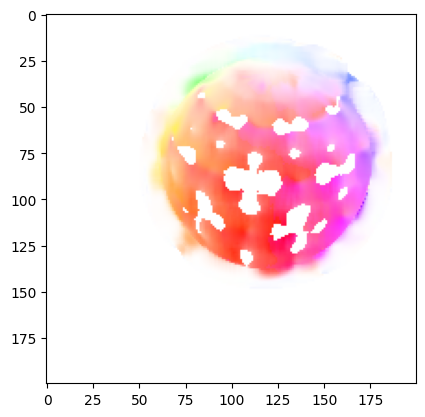

In [5]:
u,v,valid = myFlow(sphere_0, sphere_1, 9, 0.001)

flow = np.stack((u,v),axis=2)

flow_img = flowToColor(flow)

plt.imshow(flow_img)

# Effect of Window Size

In [6]:
#A smaller window size increases details but is more sensitive to noise (outliers).
#A larger window size gives 'blotchy' results as it averages over a larger window size (less sensitive to noise)

# Back Warp Comparisson

In [7]:
def myWarp(img2, u, v):
    h,w = img2.shape

    x = np.arange(w)
    y = np.arange(h)

    #Interpolator
    #interpolator = scipy.interpolate.interp2d(x,y,img2,kind='linear') #NOTE: Interp2d has been discontinued in version 1.14

    #Interpolator using new interpolate function
    interpolator = scipy.interpolate.RegularGridInterpolator((y,x), img2, method='cubic', bounds_error=False, fill_value=0)

    #Warped coordinates
    X,Y = np.meshgrid(x,y)
    X_warp = X - u
    Y_warp = Y - v

    #interpolate
    warped = interpolator(np.stack((Y_warp,X_warp), axis = -1))

    return warped

# Difference between warped images

Mean diff:  0.009569040371525424


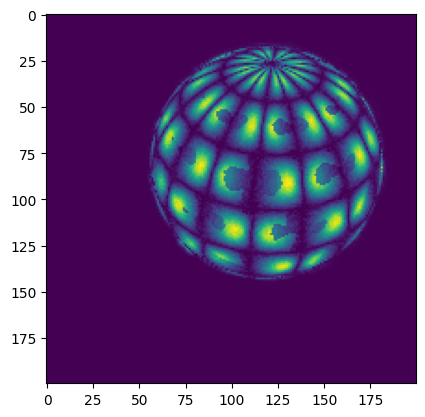

In [8]:
warped = myWarp(sphere_1, u, v)

diff = np.abs(sphere_0 - warped)
print("Mean diff: ", np.mean(diff))
plt.imshow(diff)

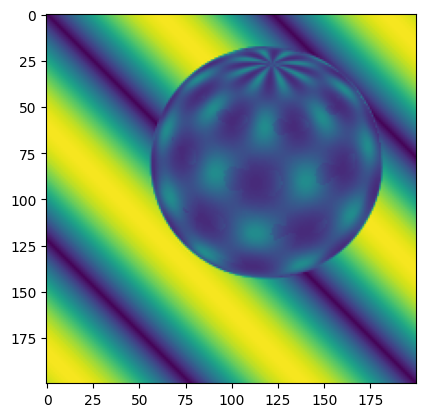

In [9]:
from IPython.display import display, clear_output #Needed to render changes in Jupyter Notebook
plt.ion()  # turn on interactive mode

fig, ax = plt.subplots()

#Swap between images
for i in range(10):
    ax.clear()
    if i % 2 == 0:
        ax.imshow(sphere_0)
    else:
        ax.imshow(warped)
    display(fig)
    clear_output(wait=True)
    plt.pause(0.5)

# Results

Text(0.5, 1.0, 'Synth Valid Map')

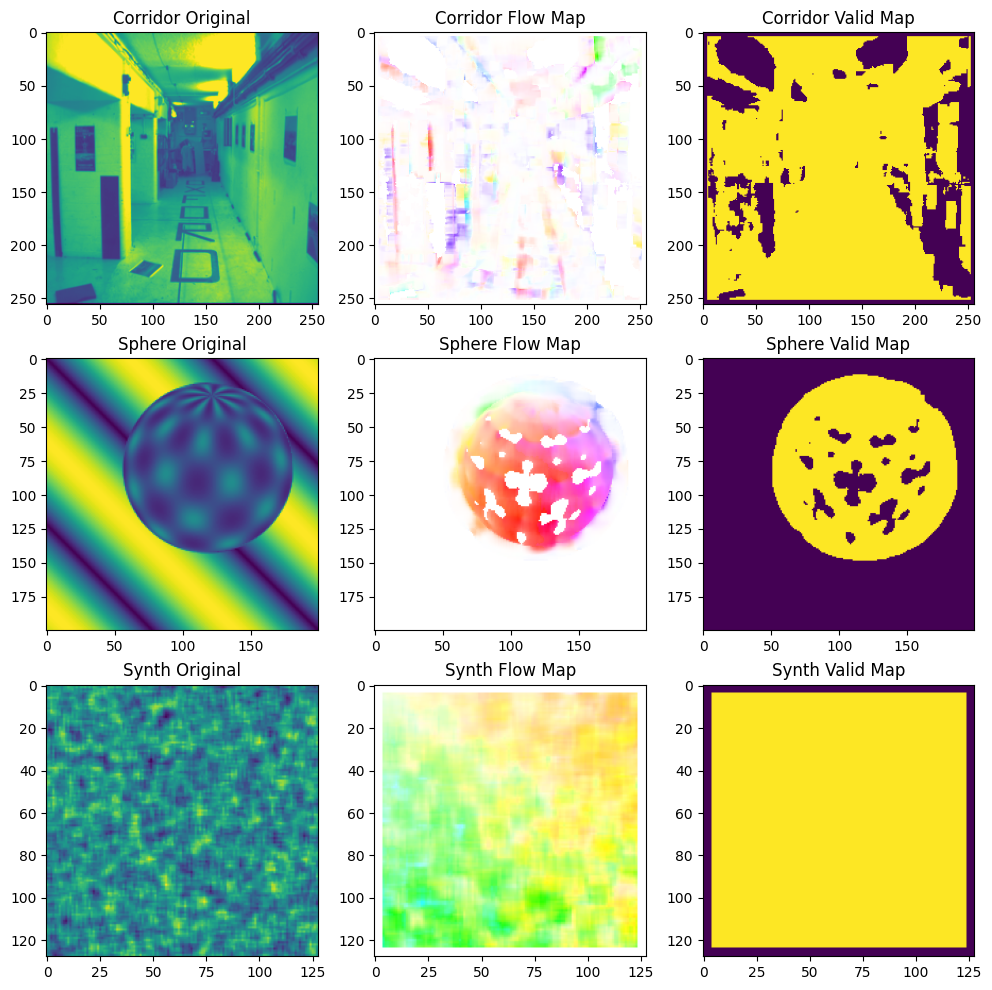

In [14]:
u_corridor,v_corridor,valid_corridor = myFlow(corridor_0, corridor_1, 9, 0.001)
u_sphere,v_sphere,valid_sphere = myFlow(sphere_0, sphere_1, 9, 0.001)
u_synth,v_synth,valid_synth = myFlow(synth_0, synth_1, 9, 0.001)

flow_corridor = np.stack((u_corridor,v_corridor),axis=2)
flow_sphere = np.stack((u_sphere,v_sphere),axis=2)
flow_synth = np.stack((u_synth,v_synth),axis=2)

flow_img_corridor = flowToColor(flow_corridor)
flow_img_sphere = flowToColor(flow_sphere)
flow_img_synth = flowToColor(flow_synth)

plt.figure(figsize=(12,12))
plt.subplot(3,3,1)
plt.imshow(corridor_0)
plt.title("Corridor Original")
plt.subplot(3,3,2)
plt.imshow(flow_img_corridor)
plt.title("Corridor Flow Map")
plt.subplot(3,3,3)
plt.imshow(valid_corridor)
plt.title("Corridor Valid Map")
plt.subplot(3,3,4)
plt.imshow(sphere_0)
plt.title("Sphere Original")
plt.subplot(3,3,5)
plt.imshow(flow_img_sphere)
plt.title("Sphere Flow Map")
plt.subplot(3,3,6)
plt.imshow(valid_sphere)
plt.title("Sphere Valid Map")
plt.subplot(3,3,7)
plt.imshow(synth_0)
plt.title("Synth Original")
plt.subplot(3,3,8)
plt.imshow(flow_img_synth)
plt.title("Synth Flow Map")
plt.subplot(3,3,9)
plt.imshow(valid_synth)
plt.title("Synth Valid Map")

# Warp Results

Text(0.5, 1.0, 'Synth Difference Map')

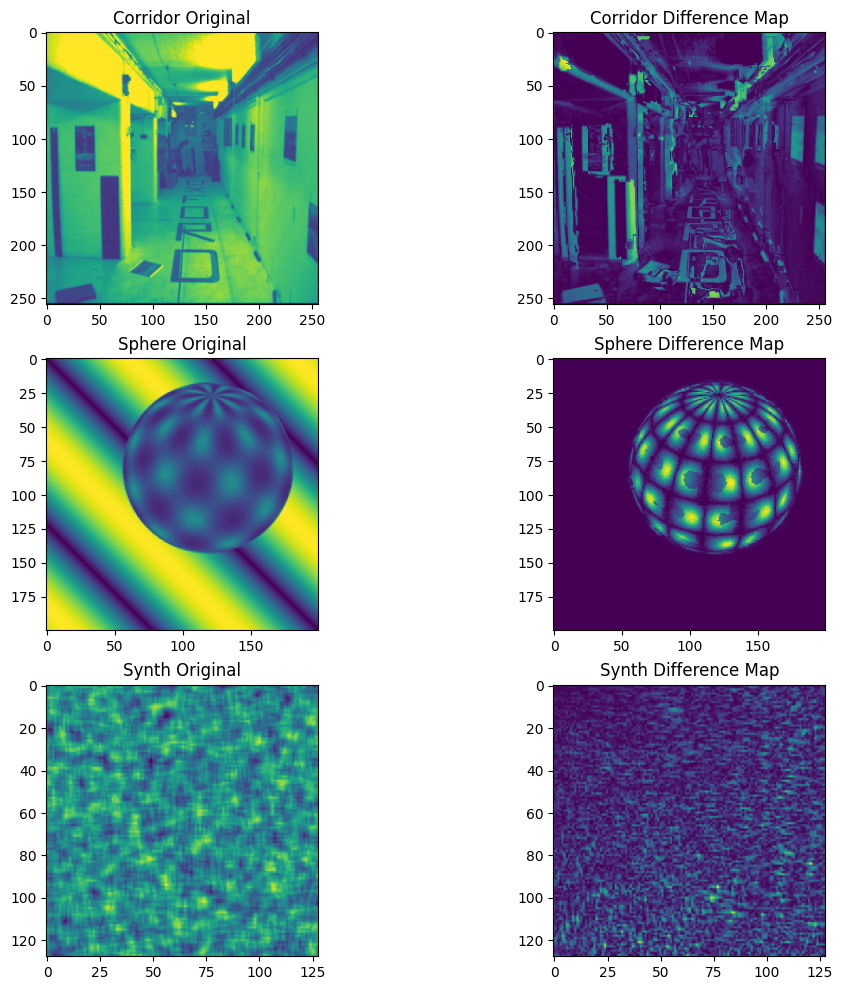

In [17]:
warped_corridor = myWarp(corridor_1, u_corridor, v_corridor)
warped_sphere = myWarp(sphere_1, u_sphere, v_sphere)
warped_synth = myWarp(synth_1, u_synth, v_synth)

diff_sphere = np.abs(sphere_0 - warped_sphere)
diff_corridor = np.abs(corridor_0 - warped_corridor)
diff_synth = np.abs(synth_0 - warped_synth)

plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
plt.imshow(corridor_0)
plt.title("Corridor Original")
plt.subplot(3,2,2)
plt.imshow(diff_corridor)
plt.title("Corridor Difference Map")
plt.subplot(3,2,3)
plt.imshow(sphere_0)
plt.title("Sphere Original")
plt.subplot(3,2,4)
plt.imshow(diff_sphere)
plt.title("Sphere Difference Map")
plt.subplot(3,2,5)
plt.imshow(synth_0)
plt.title("Synth Original")
plt.subplot(3,2,6)
plt.imshow(diff_synth)
plt.title("Synth Difference Map")

# KLT Tracker

In [18]:
def getHarrisCorners(img, sigma=5, threshold=0.001):
    #Gaussian Filter
    size = int(2*sigma*3 + 1)
    gaus = cv2.getGaussianKernel(size,sigma)
    gaus = gaus @ gaus.T

    dx = np.array([
        [1,0,-1],
        [1,0,-1],
        [1,0,-1]
    ])
    dy = dx.T

    #Calculate Gradient
    Ix = scipy.signal.convolve2d(img,dx,mode='same', boundary='symm')
    Iy = scipy.signal.convolve2d(img,dy,mode='same', boundary='symm')

    Ix2 = scipy.signal.convolve2d(Ix*Ix,gaus,mode='same', boundary='symm')
    Iy2 = scipy.signal.convolve2d(Iy*Iy,gaus,mode='same', boundary='symm')
    Ixy = scipy.signal.convolve2d(Ix*Iy,gaus,mode='same', boundary='symm')

    detM = Ix2 * Iy2 - Ixy**2
    traceM = Ix2 + Iy2

    k = 0.04 #k between 0.04 and 0.06 (from pseudocode)
    R = detM - k * (traceM**2)

    #Threshold
    R_threshold = R > threshold

    #Nonmaximum suppresion
    R_max = scipy.ndimage.maximum_filter(R, size=3)
    corners = (R == R_max) & R_threshold

    #Get keypoints from corners
    pts = np.argwhere(corners)
    pts = [(int(p[1]),int(p[0])) for p in pts]

    return pts

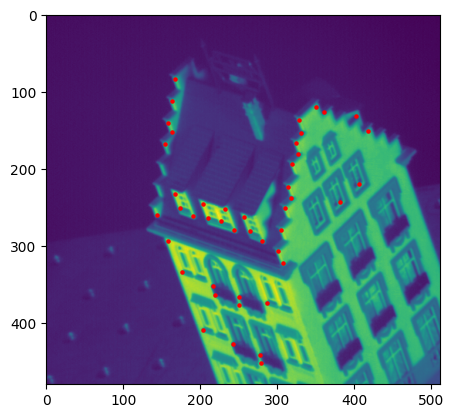

In [19]:
#Testing corner detector
hotel_seq0 = cv2.cvtColor(cv2.imread('Hotel Sequence/hotel.seq0.png'),cv2.COLOR_BGR2GRAY).astype(np.float32)/255
pts = getHarrisCorners(hotel_seq0)

plt.imshow(hotel_seq0)
for(x,y) in pts:
    plt.scatter(x,y,s=5,c='red')

# Select Random keypoints

In [20]:
import random

selected_keypoints = random.sample(pts, 20)

# Lucas-Kanade for single point

In [21]:
#Mostly copied from previous Lucas-Kanade (returns single value instead of array)
def computeFlowAtKeyPoint(img1,img2,x,y,window_size=15):
    half_window = window_size // 2

    #5-tap kernel
    kernel = np.array([-1,8,0,-8,1])/12.0
    kx = kernel.reshape(1,-1)
    ky = kernel.reshape(-1,1)

    Ix = scipy.signal.convolve2d(img1,kx,mode='same',boundary='symm')
    Iy = scipy.signal.convolve2d(img1,ky,mode='same',boundary='symm')
    It = scipy.ndimage.gaussian_filter(img2,1) - scipy.ndimage.gaussian_filter(img1,1)

    #obtain window
    Ix_window = Ix[y-half_window:y+half_window+1,x-half_window:x+half_window+1].flatten()
    Iy_window = Iy[y-half_window:y+half_window+1,x-half_window:x+half_window+1].flatten()
    It_window = It[y-half_window:y+half_window+1,x-half_window:x+half_window+1].flatten()

    #Build Matrices
    A = np.array([
        [np.sum(Ix_window*Ix_window),np.sum(Ix_window*Iy_window)],
        [np.sum(Ix_window*Iy_window), np.sum(Iy_window*Iy_window)]
    ])

    B = np.array([
        -np.sum(Ix_window*It_window),
        -np.sum(Iy_window*It_window)
    ])

    #Solve system
    if np.min(np.linalg.eigvals(A) > 0.001):
        flow = np.linalg.solve(A,B)
        return flow[0],flow[1]
    else:
        return 0,0

# Import Frames and track points

In [22]:
#Import frames
frames = []

for i in range(51):
    filename = f"Hotel Sequence/hotel.seq{i}.png"
    image = cv2.cvtColor(cv2.imread(filename),cv2.COLOR_BGR2GRAY).astype(np.float32)/255
    frames.append(image)

#Track points across frames

#Create a seperate track for each point and store in array
tracks = [ [pt] for pt in selected_keypoints ]

#iterate through frames
for t in range(len(frames)-1):
    img1 = frames[t]
    img2 = frames[t+1]

    #Index tracks and iterate through track in tracks
    for i, track in enumerate(tracks):
        if track[-1] is None:
            #Point was lost
            continue
        x,y = track[-1] #Retrieve last known location
        u,v = computeFlowAtKeyPoint(img1,img2,int(x),int(y))

        x_new = x+u
        y_new = y+v

        #Check bounds
        h,w = img1.shape
        if 0 <= x_new < w and 0 <= y_new < h:
            tracks[i].append((x_new,y_new))
        else:
            tracks[i].append(None) # point lost
            

# Display Tracking

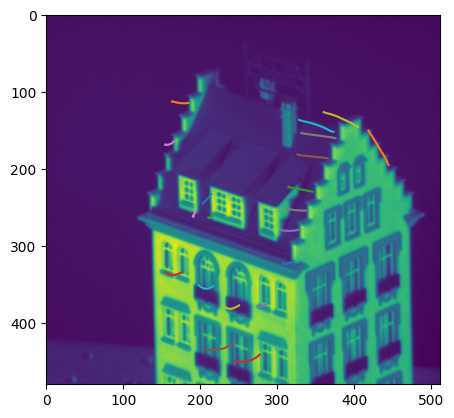

In [24]:
#Display tracking
for t in range(len(frames)):
    clear_output(wait=True)
    plt.imshow(frames[t])
    for track in tracks:
        pts = track[:t+1]
        pts = [p for p in pts if p is not None]
        if len(pts) > 1:
            x = [p[0] for p in pts]
            y = [p[1] for p in pts]
            plt.plot(x,y)
    plt.pause(0.2)


# Display Lost Tracks

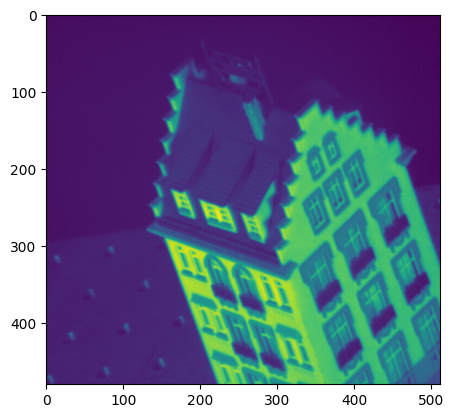

In [42]:
#Display first frame
plt.imshow(frames[0])

for track in tracks: #iterate through tracks
    if None in track: #See if any tracks were lost (marked with a none)
        #print("Lost Frame Found")
        first = track[0] #Get the first frame of lost track
        plt.plot(first[0],first[1]) #Plot first frame of lost track